In [1]:
from fastai.vision.all import *

In [2]:
import os

no_fall_list = os.listdir("is_fall/train/NoFall")

len(no_fall_list)

636

In [3]:
fall_list = os.listdir("is_fall/train/Fall")

len(fall_list)

150

## Approch 1

- Use CNN to classify fall or not fall
- The classical way

In [4]:
from make import load

no_fall = load('is_fall/train/NoFall')
fall = load('is_fall/train/Fall')

In [5]:
def remove_random_samples():
    target = len(fall_list)

    items_to_remove = len(no_fall_list) - target

    for i in range(items_to_remove):
        del no_fall[0]

remove_random_samples()

In [6]:
len(no_fall)

150

In [7]:
import os
import numpy as np

from pathlib import Path

def get_spectrograms(path:Path):
    
    result_arr = []
    labels_arr = []    

    for file in no_fall:
        labels_arr.append("No Fall")
        result_arr.append(file)

    for file in fall:
        labels_arr.append("Fall")
        result_arr.append(file)
            
    return result_arr, labels_arr

all_spectrograms, all_labels = get_spectrograms(Path("is_fall/"))

In [8]:
def get_test_spectograms(path:Path):
    result_arr = []
    labels_arr = []

    test_folders = os.listdir(path/"test")
    for folder in test_folders:
        test_files = os.listdir(path/"test"/folder)

        for file in test_files:
            arr = np.load(path/"test"/folder/file)
            labels_arr.append(folder)
            result_arr.append(arr)
            
    return result_arr, labels_arr

test_spectrograms, test_labels = get_test_spectograms(Path("is_fall/"))

In [9]:
len(all_spectrograms)

300

In [10]:
good_mask = [isinstance(a, np.ndarray) and a.ndim == 3 for a in all_spectrograms]
all_spectrograms = [a for a,m in zip(all_spectrograms, good_mask) if m]
all_labels       = [l for l,m in zip(all_labels,       good_mask) if m]

In [11]:
test_good_mask = [isinstance(a, np.ndarray) and a.ndim == 3 for a in test_spectrograms]
test_spectrograms = [a for a,m in zip(test_spectrograms, test_good_mask) if m]
test_labels       = [l for l,m in zip(test_labels, test_good_mask) if m]

In [12]:
len(test_spectrograms)

679

In [13]:
len(all_spectrograms)

278

In [14]:
print(f'Initial shape of a spectrogram: ', all_spectrograms[0].shape)

ch, freq_bins, time_bins = all_spectrograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx, time_bins)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (4, 257, 7)
Final shape: (4, 72, 7)


In [15]:
# constants you can tweak once
FLOOR_DB   = -80.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 3
EPS = 1e-12
RESIZE_HW  = None

In [16]:
def get_x(i):
    arr = all_spectrograms[i]                 # expected (C, F, T)

    # Ensure 3D
    if arr.ndim == 2:                         # (F, T) -> (1, F, T)
        arr = arr[None, ...]
    if arr.ndim != 3:
        raise ValueError(f"Expected (C,F,T), got {arr.shape} at index {i}")

    # Enforce consistent channel count to avoid 4 vs 3 errors
    C = arr.shape[0]
    if TARGET_CH is not None:
        if C < TARGET_CH:                     # pad/repeat to reach TARGET_CH
            reps = (TARGET_CH + C - 1) // C
            arr = np.tile(arr, (reps, 1, 1))[:TARGET_CH]
        elif C > TARGET_CH:                   # drop extra channels (keep last ones)
            arr = arr[-TARGET_CH:, ...]

    # --- Normalization to dB and [0,1] ---
    arr = arr.astype(np.float32)
    arr_db = 10.0 * np.log10(np.maximum(arr, EPS))  # guard against <=0
    arr_db = np.clip(arr_db, FLOOR_DB, 0.0)
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)      # [0,1]

    # Flip spectrogram (same as your original)
    arr_01 = arr_01[:, ::-1, :].copy()

    # To tensor; keep size unless RESIZE_HW is set
    t = torch.from_numpy(arr_01).float().unsqueeze(0)  # (1, C, F, T)
    if TARGET_HW is not None:
        t = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)

    return TensorImage(t.squeeze(0).contiguous())      # (C, F, T) or (C, H, W) if resized

def get_y(i):
    return all_labels[i]

In [17]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [18]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

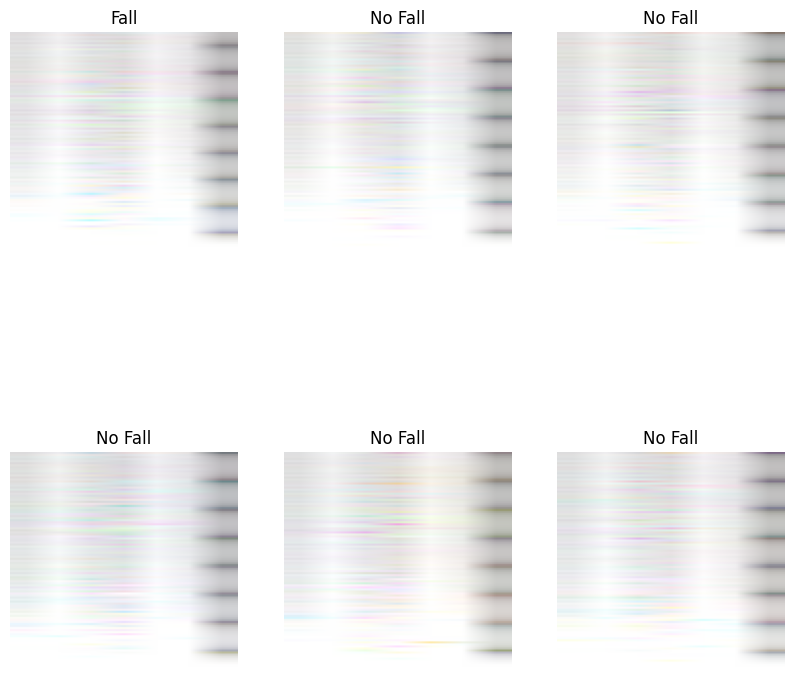

In [19]:
dls.show_batch(max_n=6, figsize=(10,10))

In [20]:
learner = vision_learner(dls, resnet18, metrics=accuracy, loss_func=CrossEntropyLossFlat())

In [21]:
learner.model[-1] = nn.Sequential(learner.model[-1], nn.ReLU())

In [22]:
learner.summary()

Sequential (Input shape: 12 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 64 x 56 x 56   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

In [23]:
learner.model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

SuggestedLRs(valley=0.002511886414140463, slide=0.12022644281387329, steep=1.3182567499825382e-06)

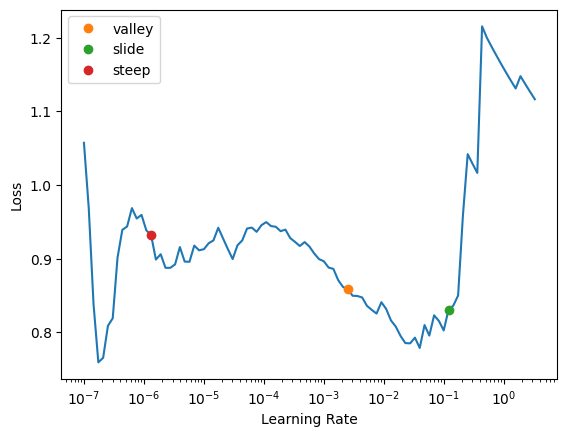

In [24]:
learner.lr_find(suggest_funcs=(valley,slide,steep))

In [25]:
learner.fit_one_cycle(25, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.936824,0.608677,0.600000,00:00
1,0.887248,0.608577,0.709091,00:00
2,0.764835,0.565555,0.781818,00:00
3,0.680291,0.545724,0.800000,00:00
4,0.610632,0.610804,0.763636,00:00
5,0.536164,0.581153,0.763636,00:00
6,0.492015,0.602663,0.800000,00:00
7,0.453950,0.575866,0.763636,00:00
8,0.406500,0.596465,0.745455,00:00
9,0.364104,0.697381,0.745455,00:00


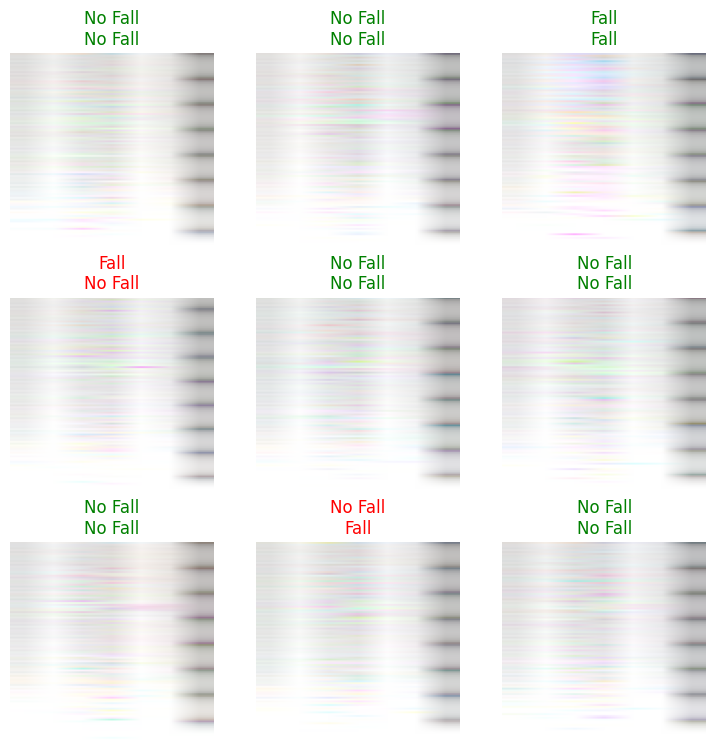

In [26]:
learner.show_results()

In [27]:
def get_x_test(i):
    arr = test_spectrograms[i]                 # expected (C, F, T)

    # Ensure 3D
    if arr.ndim == 2:                         # (F, T) -> (1, F, T)
        arr = arr[None, ...]
    if arr.ndim != 3:
        raise ValueError(f"Expected (C,F,T), got {arr.shape} at index {i}")

    # Enforce consistent channel count to avoid 4 vs 3 errors
    C = arr.shape[0]
    if TARGET_CH is not None:
        if C < TARGET_CH:                     # pad/repeat to reach TARGET_CH
            reps = (TARGET_CH + C - 1) // C
            arr = np.tile(arr, (reps, 1, 1))[:TARGET_CH]
        elif C > TARGET_CH:                   # drop extra channels (keep last ones)
            arr = arr[-TARGET_CH:, ...]

    # --- Normalization to dB and [0,1] ---
    arr = arr.astype(np.float32)
    arr_db = 10.0 * np.log10(np.maximum(arr, EPS))  # guard against <=0
    arr_db = np.clip(arr_db, FLOOR_DB, 0.0)
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)      # [0,1]

    # Flip spectrogram (same as your original)
    arr_01 = arr_01[:, ::-1, :].copy()

    # To tensor; keep size unless RESIZE_HW is set
    t = torch.from_numpy(arr_01).float().unsqueeze(0)  # (1, C, F, T)
    if TARGET_HW is not None:
        t = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)

    return TensorImage(t.squeeze(0).contiguous())      # (C, F, T) or (C, H, W) if resized

def get_y_test(i):
    return test_labels[i]

In [28]:
len(test_spectrograms)

679

In [29]:
len(test_labels)

679

In [30]:
get_y_test(600)

'NoFall'

In [31]:
get_y_test(600) == learner.predict(get_x_test(600))[0]

False

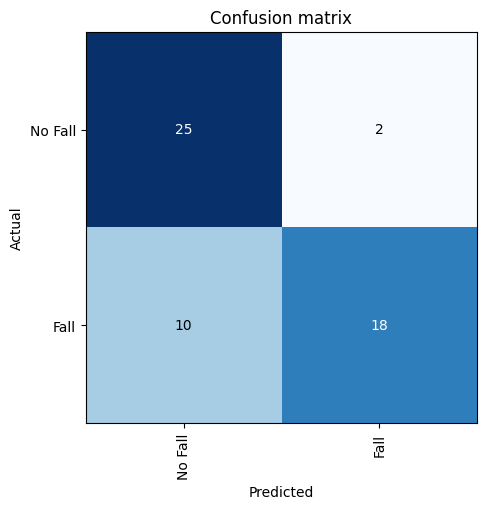

In [32]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [33]:
def get_val_accuracy(learner : Learner, test_set):

    base = min(len(test_spectrograms), len(test_labels))

    true_count = 0

    for i in range(base):
        if learner.predict(get_x_test(i))[0] == get_y_test(i):
            true_count += 1
    
    print(base)

    
    return true_count / base

In [34]:
accuracy = get_val_accuracy(learner, test_spectrograms)

679


In [35]:
accuracy

0.15169366715758467

In [36]:
dir = Path('./models')

learner.path = dir

learner.export('autoencoder.pkl')

## Approch 2

- Threat the spectrogram arrays as a vector embedding, and compare the sematics to the training data.
- Stupid and fast. 
